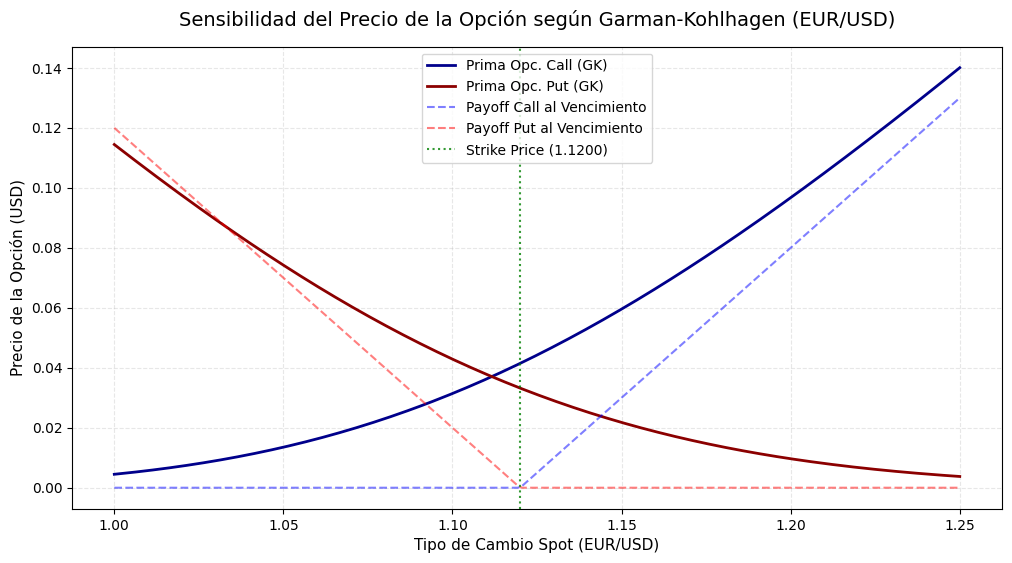

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def garman_kohlhagen(S, K, T, rd, rf, sigma, option_type="call"):
    # Calcula el precio de una opción FX europea usando el modelo Garman-Kohlhagen.
    # Evitar divisiones por cero o logaritmos negativos si el spot es cero o inferior
    S = np.maximum(S, 1e-5)

    d1 = (np.log(S / K) + (rd - rf + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        price = S * np.exp(-rf * T) * norm.cdf(d1) - K * np.exp(-rd * T) * norm.cdf(d2)
    elif option_type == "put":
        price = K * np.exp(-rd * T) * norm.cdf(-d2) - S * np.exp(-rf * T) * norm.cdf(-d1)
    else:
        raise ValueError("option_type debe ser 'call' o 'put'")

    return price

# PARÁMETROS DEL EJEMPLO (EUR/USD)
K_strike = 1.12  # Strike precio de ejercicio
T_years = 0.5    # Tiempo en años (6 meses)
r_dom = 0.045    # Tasa Doméstica (USD: 4.5%)
r_for = 0.030    # Tasa Extranjera (EUR: 3.0%)
vol = 0.12       # Volatilidad anualizada (12%)

# GENERACIÓN DE DATOS PARA LA GRÁFICA
# Rango de precios Spot desde 1.00 hasta 1.25
spot_range = np.linspace(1.00, 1.25, 200)

# Calcular los precios de Call y Put para cada punto del rango
call_prices = [garman_kohlhagen(s, K_strike, T_years, r_dom, r_for, vol, "call") for s in spot_range]
put_prices = [garman_kohlhagen(s, K_strike, T_years, r_dom, r_for, vol, "put") for s in spot_range]

# Calcular el valor intrínseco al vencimiento (Payoff de ejercicio)
call_payoff = np.maximum(spot_range - K_strike, 0)
put_payoff = np.maximum(K_strike - spot_range, 0)

# CREACIÓN DE LA GRÁFICA
plt.figure(figsize=(12, 6))

# Dibujar curvas del modelo Garman-Kohlhagen (Valor Temporal + Intrínseco)
plt.plot(spot_range, call_prices, label='Prima Opc. Call (GK)', color='darkblue', lw=2)
plt.plot(spot_range, put_prices, label='Prima Opc. Put (GK)', color='darkred', lw=2)

# Dibujar líneas de Payoff al vencimiento (Líneas de trazo discontinuo)
plt.plot(spot_range, call_payoff, label='Payoff Call al Vencimiento', color='blue', linestyle='--', alpha=0.5)
plt.plot(spot_range, put_payoff, label='Payoff Put al Vencimiento', color='red', linestyle='--', alpha=0.5)

# Línea de referencia para el Strike
plt.axvline(x=K_strike, color='green', linestyle=':', label=f'Strike Price ({K_strike:.4f})', alpha=0.8)

# Configuración de etiquetas y diseño
plt.title('Sensibilidad del Precio de la Opción según Garman-Kohlhagen (EUR/USD)', fontsize=14, pad=15)
plt.xlabel('Tipo de Cambio Spot (EUR/USD)', fontsize=11)
plt.ylabel('Precio de la Opción (USD)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper center', frameon=True)

# Mostrar el gráfico
plt.show()
